# Dense Point-Cloud Reconstruction

Implements the second stage of *[Automated Low-Cost Photogrammetric Acquisition of 3D Models from
Small Form-Factor Artefacts](https://www.mdpi.com/2079-9292/8/12/1441)* (Collins et al., 2019),
following on from [camera_geometry_estimation.ipynb](camera_geometry_estimation.ipynb).

The paper uses CMVS/PMVS (Furukawa's clustering-views-for-multi-view-stereo toolchain) for dense
reconstruction. That toolchain has no pip package, is unmaintained, and COLMAP's own docs describe
it as superseded by COLMAP's own dense pipeline - **PatchMatchStereo** (per-image depth/normal maps)
followed by **StereoFusion** (merging those into one point cloud) - which is what this notebook uses
instead, via the same `pycolmap` library already used for calibration.

**Important: this needs a CUDA-enabled pycolmap, which the regular Windows pip wheel is not.**

**Pipeline in this notebook:**
1. Load the calibrated real cameras + sparse point cloud from Step 4 (`outputs/<set>/final`), and
   locate the same downscaled real photographs Step 4 already calibrated against
   (`outputs/<set>/work`) - no separate copy/downscale/rescale needed, since PatchMatchStereo works
   from *some* undistorted resolution regardless, and reusing Step 4's keeps that resolution choice
   in one place. Full 4000x3000 photos measured ~60-90s/image for PatchMatchStereo on this GPU -
   intractable for a whole set, hence Step 4 downscaling in the first place.
2. Undistort those working-resolution images into a COLMAP dense workspace.
3. Run PatchMatchStereo (GPU) for per-image depth + normal maps.
4. Run StereoFusion to merge depth maps into one dense, coloured point cloud.
5. Restrict to a region of interest around the artefact (a rough spatial filter - not the paper's
   dedicated cropping stage, which comes later) and attempt to hit target point densities (points
   per mm&sup2; of the artefact's bounding-box surface area, standing in for actual surface area
   until a mesh exists).

In [10]:
from pathlib import Path
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pycolmap

from utils import dense_reconstruction as dr

## Parameters

In [11]:
SET_NAME = "set_2"

ROOT = Path.cwd()
FINAL_DIR = ROOT / "outputs" / SET_NAME / "final"    # Step 4's output
CALIB_WORK_DIR = ROOT / "outputs" / SET_NAME / "work"  # Step 4's own downscaled real photos
OUT_DIR = ROOT / "outputs" / SET_NAME / "dense"
SPARSE_DIR = OUT_DIR / "sparse"
WORKSPACE_DIR = OUT_DIR / "workspace"
FUSED_DIR = OUT_DIR / "fused"

# PatchMatchStereo (requires CUDA - see the notebook intro for WSL/pycolmap-cuda12 setup)
PATCH_MATCH_MAX_IMAGE_SIZE = -1  # -1 = use the (already downscaled) working images at full size
PATCH_MATCH_WINDOW_RADIUS = 5
PATCH_MATCH_NUM_ITERATIONS = 5

# StereoFusion
FUSION_MIN_NUM_PIXELS = 5
FUSION_MAX_REPROJ_ERROR = 2.0
FUSION_MAX_DEPTH_ERROR = 0.01

# Rough region-of-interest filter around the artefact (see Step 6) - not the paper's dedicated
# cropping stage, which comes later and would do this more precisely.
ROI_RADIUS_MM = 65.0

# Target point densities requested for this step. Spoiler from validating this notebook: with a
# phone camera at ~20-25cm from a ~32mm object, downscaled for tractable runtime, the achievable
# density measured around 5-10 points/mm^2 - one to two orders of magnitude below these targets.
# Kept as explicit targets anyway so the gap is visible rather than silently substituting a
# different number; see Step 7 for the honest achieved-vs-target comparison.
DENSITY_TARGETS_PER_MM2 = [100.0, 300.0]

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load the calibrated reconstruction

The real cameras (poses + intrinsics) and sparse point cloud written by
`camera_geometry_estimation.ipynb`.

In [12]:
recon = dr.load_calibrated_reconstruction(FINAL_DIR)
print(recon.summary())

calib_camera = list(recon.cameras.values())[0]
print(f"calibration resolution: {calib_camera.width}x{calib_camera.height}")

real_names = sorted(img.name for img in recon.images.values() if img.has_pose)
print(f"{len(real_names)} calibrated real cameras")

missing = [name for name in real_names if not (CALIB_WORK_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"{len(missing)} of Step 4's working images are missing from {CALIB_WORK_DIR} "
        "(e.g. camera_geometry_estimation.ipynb was re-run since, which clears that folder). "
        "Re-run Step 4 for this set before this notebook."
    )
print(f"found all {len(real_names)} of Step 4's downscaled working images in {CALIB_WORK_DIR}")

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 26
	num_reg_frames = 26
	num_images = 26
	num_points3D = 12284
	num_observations = 59575
	mean_track_length = 4.8498
	mean_observations_per_image = 2291.35
	mean_reprojection_error = 0.702478
calibration resolution: 3000x2250
26 calibrated real cameras
found all 26 of Step 4's downscaled working images in /home/gnoceras/ScanningTable/outputs/set_2/work


## Step 2 - Undistort for dense stereo

Reuses the exact photographs Step 4 already downscaled and calibrated against (no separate
re-downscale, and no intrinsics rescaling - the calibrated camera already matches this
resolution). COLMAP's dense stereo pipeline expects an undistorted/pinhole workspace, not the
original (possibly radially distorted) photos, so that's the only transform needed here.

In [13]:
t0 = time.time()
undistorted_names = dr.undistort_for_stereo(
    recon, SPARSE_DIR, CALIB_WORK_DIR, WORKSPACE_DIR, max_image_size=-1
)
print(f"undistorted {len(undistorted_names)} images in {time.time()-t0:.1f}s -> {WORKSPACE_DIR}")

I20260716 15:55:53.459133 130410115729216 images.cc:122]  => Reconstruction with 26 images and 12284 points
I20260716 15:55:53.461912 130410115729216 undistorters.cc:166] === Image undistortion ===
I20260716 15:55:53.474622 130410115729216 undistorters.cc:205] Undistorting image [1/26]
I20260716 15:55:56.538800 130410115729216 undistorters.cc:205] Undistorting image [2/26]
I20260716 15:55:56.538845 130410115729216 undistorters.cc:205] Undistorting image [3/26]
I20260716 15:55:56.538851 130410115729216 undistorters.cc:205] Undistorting image [4/26]
I20260716 15:55:56.538853 130410115729216 undistorters.cc:205] Undistorting image [5/26]
I20260716 15:55:56.538855 130410115729216 undistorters.cc:205] Undistorting image [6/26]
I20260716 15:55:56.538857 130410115729216 undistorters.cc:205] Undistorting image [7/26]
I20260716 15:55:56.538859 130410115729216 undistorters.cc:205] Undistorting image [8/26]
I20260716 15:55:56.710067 130410115729216 undistorters.cc:205] Undistorting image [9/26]
I

undistorted 26 images in 4.2s -> /home/gnoceras/ScanningTable/outputs/set_2/dense/workspace


I20260716 15:55:57.393229 130410115729216 undistorters.cc:205] Undistorting image [22/26]
I20260716 15:55:57.393268 130410115729216 undistorters.cc:205] Undistorting image [23/26]
I20260716 15:55:57.393271 130410115729216 undistorters.cc:205] Undistorting image [24/26]
I20260716 15:55:57.410632 130410115729216 undistorters.cc:205] Undistorting image [25/26]
I20260716 15:55:57.461520 130410115729216 undistorters.cc:205] Undistorting image [26/26]
I20260716 15:55:57.512801 130410115729216 undistorters.cc:213] Writing reconstruction...
I20260716 15:55:57.576740 130410115729216 undistorters.cc:218] Writing configuration...
I20260716 15:55:57.577214 130410115729216 undistorters.cc:222] Writing scripts...
I20260716 15:55:57.577407 130410115729216 timer.cc:90] Elapsed time: 0.069 [minutes]


## Step 3 - PatchMatchStereo

Per-image depth and normal maps, geometrically-consistency-checked across neighbouring views.
**Requires the CUDA kernel from the notebook intro** - this is the step that fails with
"Dense stereo reconstruction requires CUDA" on the regular Windows pycolmap wheel.

This is the slow step: expect on the order of a minute per image at Step 4's working resolution
(more at a higher resolution - re-run Step 4 with a larger `MAX_LONG_EDGE` first if you want to
trade runtime for a shot at higher point density, see Step 5 below).

In [14]:
t0 = time.time()
dr.run_patch_match_stereo(
    WORKSPACE_DIR,
    max_image_size=PATCH_MATCH_MAX_IMAGE_SIZE,
    window_radius=PATCH_MATCH_WINDOW_RADIUS,
    num_iterations=PATCH_MATCH_NUM_ITERATIONS,
)
print(f"patch_match_stereo elapsed: {time.time()-t0:.1f}s")

I20260716 15:55:57.590214 130410115729216 patch_match.cc:210] Reading workspace...
I20260716 15:55:57.610262 130410115729216 patch_match.cc:240] Reading configuration...
I20260716 15:55:57.631451 130410115729216 patch_match.cc:371] Configuration has 26 problems...
I20260716 15:55:57.635354 130402110924480 patch_match.cc:416] === Processing view 1 / 26 for set_2/02_stop_06_20260715_172249.jpg ===
I20260716 15:55:57.635398 130402110924480 patch_match.cc:466] Reading inputs...
I20260716 15:55:57.785968 130402110924480 patch_match.cc:56] --- PatchMatch::Problem ---
I20260716 15:55:57.786010 130402110924480 patch_match.cc:57] ref_image_idx: 5
I20260716 15:55:57.786046 130402110924480 patch_match.cc:64] src_image_idxs: 17 13 23 22 18 21 19 4 6 7 20 3 8 2 9 1 10 0 11 12
I20260716 15:55:57.786107 130402110924480 patch_match_options.cc:46] --- PatchMatchOptions ---
I20260716 15:55:57.786110 130402110924480 patch_match_options.cc:47] max_image_size: -1
I20260716 15:55:57.786111 130402110924480 p

patch_match_stereo elapsed: 1887.6s


Sanity check: one depth map, to confirm PatchMatchStereo actually produced per-pixel depth (not just silently no-oping).

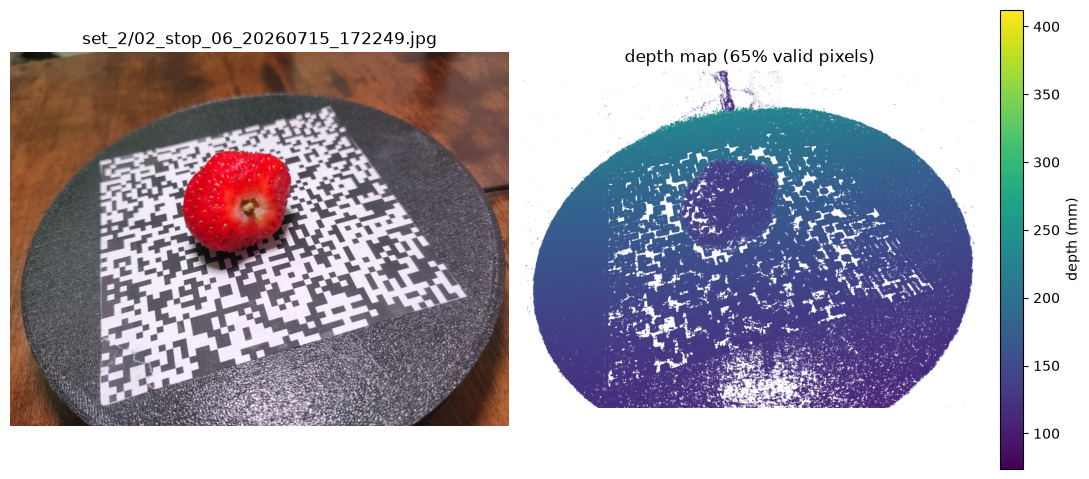

In [15]:
sample_depth_path = WORKSPACE_DIR / "stereo" / "depth_maps" / f"{undistorted_names[0]}.geometric.bin"
depth = dr.read_depth_map(sample_depth_path)
valid_frac = np.count_nonzero(depth) / depth.size
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(str(WORKSPACE_DIR / "images" / undistorted_names[0])), cv2.COLOR_BGR2RGB))
axes[0].set_title(undistorted_names[0]); axes[0].axis("off")
masked = np.ma.masked_where(depth == 0, depth)
im = axes[1].imshow(masked, cmap="viridis")
axes[1].set_title(f"depth map ({valid_frac:.0%} valid pixels)"); axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="depth (mm)", fraction=0.046)
plt.tight_layout()
plt.show()

## Step 4 - Stereo fusion

Merge every image's depth/normal maps into one dense, coloured point cloud.

In [16]:
t0 = time.time()
fused = dr.run_stereo_fusion(
    WORKSPACE_DIR, FUSED_DIR,
    min_num_pixels=FUSION_MIN_NUM_PIXELS,
    max_reproj_error=FUSION_MAX_REPROJ_ERROR,
    max_depth_error=FUSION_MAX_DEPTH_ERROR,
)
print(f"stereo_fusion elapsed: {time.time()-t0:.1f}s")
print(f"fused points: {fused.num_points3D()}")

points, colors = dr.points_and_colors(fused)
print("bounding box min/max (mm):", points.min(axis=0), points.max(axis=0))

I20260716 16:27:30.919417 130410115729216 fusion.cc:79] --- StereoFusion::Options ---
I20260716 16:27:30.919487 130410115729216 fusion.cc:80] mask_path: ""
I20260716 16:27:30.920211 130410115729216 fusion.cc:81] max_image_size: -1
I20260716 16:27:30.920222 130410115729216 fusion.cc:82] min_num_pixels: 5
I20260716 16:27:30.920224 130410115729216 fusion.cc:83] max_num_pixels: 10000
I20260716 16:27:30.920226 130410115729216 fusion.cc:84] max_traversal_depth: 100
I20260716 16:27:30.920229 130410115729216 fusion.cc:85] max_reproj_error: 2
I20260716 16:27:30.920242 130410115729216 fusion.cc:86] max_depth_error: 0.01
I20260716 16:27:30.920246 130410115729216 fusion.cc:87] max_normal_error: 10
I20260716 16:27:30.920250 130410115729216 fusion.cc:88] check_num_images: 50
I20260716 16:27:30.920252 130410115729216 fusion.cc:89] use_cache: 0
I20260716 16:27:30.920255 130410115729216 fusion.cc:90] cache_size: 32
I20260716 16:27:30.920258 130410115729216 fusion.cc:93] bbox_min: -3.40282e+38 -3.40282e

stereo_fusion elapsed: 67.0s
fused points: 2968784
bounding box min/max (mm): [-119.53874207 -100.92542267  -70.74279022] [105.61169434 155.29333496 196.4362793 ]


## Raw dense point cloud

Coloured by the photographs' own pixel values. Subsampled for plotting only - the full cloud is what gets written to disk.

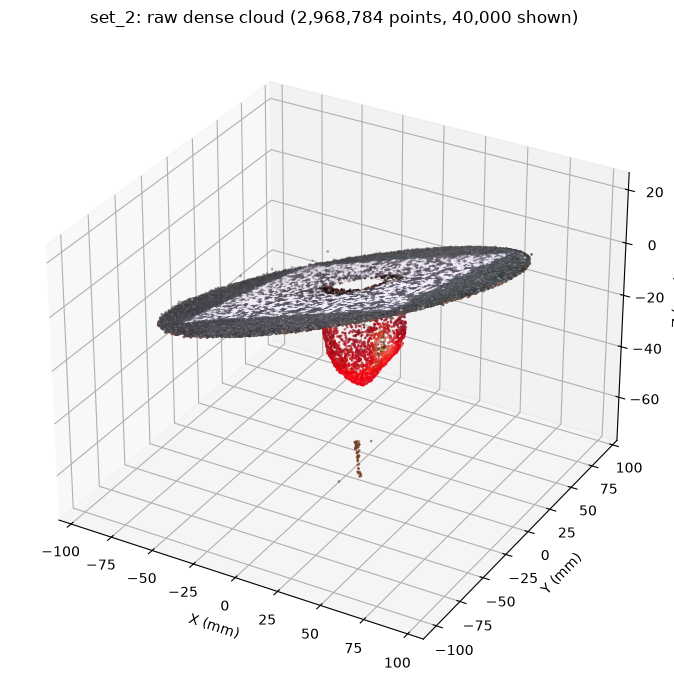

In [21]:
plot_sample = np.random.default_rng(0).choice(len(points), size=min(40_000, len(points)), replace=False)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    points[plot_sample, 0], points[plot_sample, 1], points[plot_sample, 2],
    c=colors[plot_sample] / 255.0, s=1,
)
ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
ax.set_title(f"{SET_NAME}: raw dense cloud ({len(points):,} points, {len(plot_sample):,} shown)")
plt.tight_layout()
plt.show()

## Step 5 - Region of interest and achieved density

Exhaustive real&harr;real stereo also reconstructs the calibration plate and any well-textured
background, not just the artefact - restrict to a rough sphere around the world origin (where the
plate is centred) before computing density, or the plate's own flat surface would dominate the
count. Surface area is approximated as the ROI points' axis-aligned bounding-box surface area
(no mesh exists yet at this stage of the pipeline).

In [22]:
roi_points, roi_colors = dr.filter_by_radius(points, colors, radius_mm=ROI_RADIUS_MM)
print(f"ROI (radius={ROI_RADIUS_MM}mm): {len(roi_points)} / {len(points)} points")

roi_area_mm2 = dr.bounding_box_surface_area_mm2(roi_points)
raw_density = len(roi_points) / roi_area_mm2
print(f"ROI bounding-box surface area: {roi_area_mm2:.0f} mm^2")
print(f"raw achieved density: {raw_density:.2f} points/mm^2")

dr.write_ply(OUT_DIR / "dense_raw.ply", roi_points, roi_colors)
print(f"wrote {OUT_DIR / 'dense_raw.ply'}")

ROI (radius=65.0mm): 1317085 / 2968784 points
ROI bounding-box surface area: 71000 mm^2
raw achieved density: 18.55 points/mm^2
wrote /home/gnoceras/ScanningTable/outputs/set_2/dense/dense_raw.ply


## Step 6 - Downsample towards the target densities

`downsample_to_density` voxel-downsamples towards a target; if the raw cloud is already sparser
than the target (as above), it's returned unchanged - no amount of downsampling can invent points
a camera never resolved. Both target outputs are written regardless, clearly named, so downstream
steps can use whichever a given target actually needs.

In [19]:
results = []
for target in DENSITY_TARGETS_PER_MM2:
    out_points, out_colors, achieved, reached_target = dr.downsample_to_density(
        roi_points, roi_colors, target, roi_area_mm2
    )
    out_path = OUT_DIR / f"dense_{int(target)}ppmm2.ply"
    dr.write_ply(out_path, out_points, out_colors)
    results.append((target, len(out_points), achieved, reached_target, out_path))
    status = "reached" if reached_target else "NOT reached (raw cloud is already sparser than this)"
    print(f"target={target:.0f} pts/mm^2: {len(out_points):,} points, achieved={achieved:.2f} pts/mm^2 - {status}")
    print(f"  wrote {out_path}")

target=100 pts/mm^2: 1,317,085 points, achieved=18.55 pts/mm^2 - NOT reached (raw cloud is already sparser than this)
  wrote /home/gnoceras/ScanningTable/outputs/set_2/dense/dense_100ppmm2.ply
target=300 pts/mm^2: 1,317,085 points, achieved=18.55 pts/mm^2 - NOT reached (raw cloud is already sparser than this)
  wrote /home/gnoceras/ScanningTable/outputs/set_2/dense/dense_300ppmm2.ply


## Summary

In [20]:
print(f"{SET_NAME}")
print(f"  raw fused points:        {len(points):,}")
print(f"  ROI points (r={ROI_RADIUS_MM:.0f}mm):     {len(roi_points):,}  ({raw_density:.2f} pts/mm^2 over {roi_area_mm2:.0f} mm^2)")
for target, n, achieved, reached, path in results:
    print(f"  target {target:>5.0f} pts/mm^2: {n:,} points, {achieved:.2f} pts/mm^2 achieved ({'OK' if reached else 'target unreachable with this data'})")

set_2
  raw fused points:        2,968,784
  ROI points (r=65mm):     1,317,085  (18.55 pts/mm^2 over 71000 mm^2)
  target   100 pts/mm^2: 1,317,085 points, 18.55 pts/mm^2 achieved (target unreachable with this data)
  target   300 pts/mm^2: 1,317,085 points, 18.55 pts/mm^2 achieved (target unreachable with this data)
